# Imports

In [25]:
import sys
import os
from os.path import sep
import numpy as np
import matplotlib.pyplot as plt

# Local modules
sys.path.append('Documents{0}CEGIS{0}discsim{0}api{0}utils{0}Pre Survey Nested Simulation'.format(sep))
from AS_extract_data_from_dta_file import extract_data_from_dta


Matplotlib is building the font cache; this may take a moment.


# NHFS-5

## Load data

In [4]:
cd

/Users/amritasingh


/Users/amritasingh/Documents/CEGIS/discsim/api/utils/Pre Survey Nested Simulation/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:393: UserWarning: using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})
/Users/amritasingh/Documents/CEGIS/discsim/api/utils/Pre Survey Nested Simulation/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:428: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [11]:
file_path ='Documents{0}CEGIS{0}DiscSim_figures_and_data{0}NHFS-5 data{0}NHFS-5 data from SP - CORRECT COLUMN NAMES PR{0}IAPR7AFL.DTA'.format(sep)
data = extract_data_from_dta(file_path, convert_categoricals=False)

In [12]:
data

,hhid,hvidx,hv000,hv001,hv002,hv003,hv004,hv005,hv006,hv007,...,hml32b,hml32c,hml32d,hml32e,hml32f,hml32g,hml33,hml34,hml35,hml36
0,0100101305,1,IA7,113,5,1,113,196202,9,2019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
1,0100101305,2,IA7,113,5,1,113,196202,9,2019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
2,0100101305,3,IA7,113,5,1,113,196202,9,2019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
3,0100101305,4,IA7,113,5,1,113,196202,9,2019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
4,0100101305,5,IA7,113,5,1,113,196202,9,2019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2843912,3700401592,1,IA7,415,92,4,415,50597,9,2019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
2843913,3700401592,2,IA7,415,92,4,415,50597,9,2019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
2843914,3700401592,3,IA7,415,92,4,415,50597,9,2019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
2843915,3700401592,4,IA7,415,92,4,415,50597,9,2019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN


Relevant column labels from .DO file:

label variable hc1      "Child's age in months"

label variable hc1a     "Child's age in days"

label variable hc2      "Child's weight in kilograms (1 decimal)"

label variable hc3      "Child's height in centimeters (1 decimal)"

label variable hc4      "Height/Age percentile"

label variable hc5      "Height/Age standard deviation"

label variable hc6      "Height/Age percent of ref. median"

label variable hc7      "Weight/Age percentile"

label variable hc8      "Weight/Age standard deviation"

label variable hc9      "Weight/Age percent of ref. median"

label variable hc10     "Weight/Height percentile"

label variable hc11     "Weight/Height standard deviation"

label variable hc12     "Weight/Height percent of ref. median"

label variable hc13     "Result of measurement - height/weight"

label variable hc15     "Height: lying or standing"

label variable hc27     "Sex"

## Processing

Values to exclude (from .DO file):

label define HC2     
  9994 "Not present"
  9995 "Refused"
  9996 "Other"
;

label define HC3     
  9994 "Not present"
  9995 "Refused"
  9996 "Other"
;

label define HC4     
  9998 "Flagged cases"
;

label define HC5     
  9998 "Flagged cases"
;

label define HC6     
 99998 "Flagged cases"
;

label define HC7     
  9998 "Flagged cases"
;

label define HC8     
  9998 "Flagged cases"
;

label define HC9     
 99998 "Flagged cases"
;

label define HC10    
  9998 "Flagged cases"
;

label define HC11    
  9998 "Flagged cases"
;

label define HC12    
 99998 "Flagged cases"
;


### Exclude rows with 'Not present', 'Refused', or 'Other' for height or weight

In [30]:
excl_values = [9994, 9995, 9996]
data.drop(data[(data['hc2'].isin(excl_values)) | (data['hc3'].isin(excl_values))].index, inplace=True)

### Exclude rows with 'Flagged cases' for HAP, WAP, HAZ, WAZ, WHP or WHZ

In [33]:
excl_values = [9998]
data.drop(data[(data['hc4'].isin(excl_values)) | (data['hc5'].isin(excl_values)) | (data['hc7'].isin(excl_values)) | (data['hc8'].isin(excl_values)) | (data['hc10'].isin(excl_values))].index, inplace=True)

## Get data into lists

In [45]:
age = data['hc1a']
weight = data['hc2']
height = data['hc3']
hap = data['hc4']
haz = data['hc5']
wap = data['hc7']
waz = data['hc8']
whp = data['hc10']
whz = data['hc11']
sex = data['hc27']

## Plot data

Text(0.5, 1.0, 'WAP Distribution')

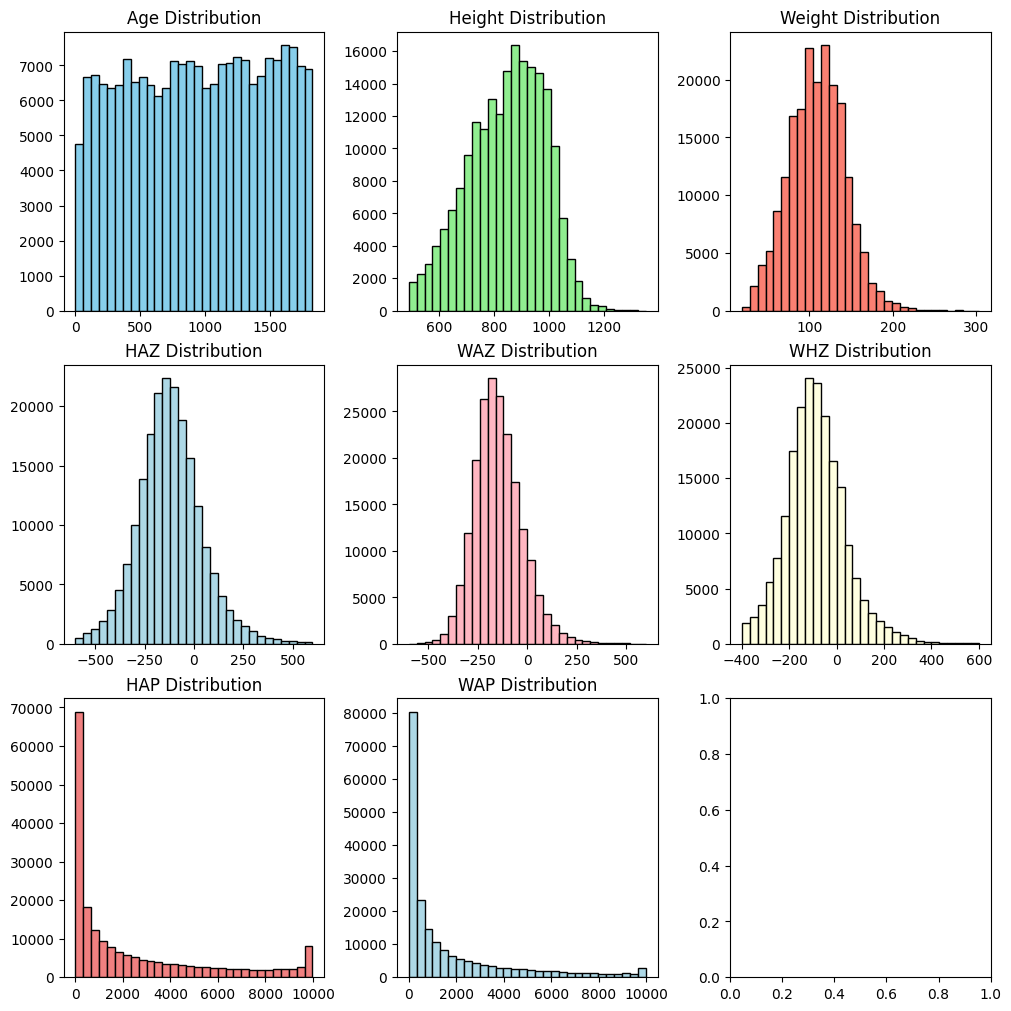

In [35]:
fig, ax = plt.subplots(3, 3, figsize=(10, 10), constrained_layout = True)  

# Age distribution
ax[0, 0].hist(age.dropna(), bins=30, color='skyblue', edgecolor='black')
ax[0, 0].set_title('Age Distribution')

# Height distribution
ax[0, 1].hist(height.dropna(), bins=30, color='lightgreen', edgecolor='black')
ax[0, 1].set_title('Height Distribution')   

# Weight distribution
ax[0, 2].hist(weight.dropna(), bins=30, color='salmon', edgecolor='black')
ax[0, 2].set_title('Weight Distribution')

# HAZ distribution
ax[1, 0].hist(haz.dropna(), bins=30, color='lightblue', edgecolor='black')
ax[1, 0].set_title('HAZ Distribution')

# WAZ distribution
ax[1, 1].hist(waz.dropna(), bins=30, color='lightpink', edgecolor='black')
ax[1, 1].set_title('WAZ Distribution')

# WHZ distribution
ax[1, 2].hist(whz.dropna(), bins=30, color='lightyellow', edgecolor='black')
ax[1, 2].set_title('WHZ Distribution')

# HAP distribution
ax[2, 0].hist(hap.dropna(), bins=30, color='lightcoral', edgecolor='black')
ax[2, 0].set_title('HAP Distribution')

# WAP distribution
ax[2, 1].hist(wap.dropna(), bins=30, color='lightblue', edgecolor='black')
ax[2, 1].set_title('WAP Distribution')


Text(0, 0.5, 'Height (cm)')

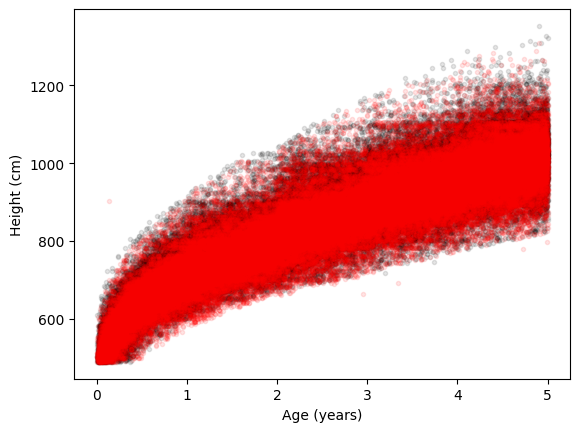

In [49]:
boys = sex[sex == 1]
girls = sex[sex == 2]
plt.figure()
plt.scatter(age[boys.index]/365, height[boys.index], color = 'k', marker = '.', alpha = 0.1, label = 'Boys')
plt.scatter(age[girls.index]/365, height[girls.index], color = 'r', marker = '.', alpha = 0.1, label = 'Girls')
plt.xlabel('Age (years)')
plt.ylabel('Height (cm)')

# NHTS: Jan - March 2025, 3 districts

## Load data

In [1]:
cd

/Users/amritasingh


/Users/amritasingh/Documents/CEGIS/discsim/api/utils/Pre Survey Nested Simulation/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:393: UserWarning: using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})
/Users/amritasingh/Documents/CEGIS/discsim/api/utils/Pre Survey Nested Simulation/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:428: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]
